# Case Study: Predicting Attorney Representation in Insurance claims
# using LogisticRegression Model

In [1]:
# import library
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv('CSV_file\\claimants.csv')

In [3]:
data.head()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CASENUM   1340 non-null   int64  
 1   ATTORNEY  1340 non-null   int64  
 2   CLMSEX    1328 non-null   float64
 3   CLMINSUR  1299 non-null   float64
 4   SEATBELT  1292 non-null   float64
 5   CLMAGE    1151 non-null   float64
 6   LOSS      1340 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 73.4 KB


In [5]:
data.shape

(1340, 7)

In [6]:
len(data['CASENUM'].unique())

1283

In [7]:
# drop irrelevant columns

In [8]:
data = data.drop(columns = ['CASENUM'])

In [9]:
data.isna().sum()

ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [10]:
data.shape

(1340, 6)

In [13]:
## drop the null value 
data = data.dropna()

In [14]:
data.isna().sum()

ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

In [150]:
data.head()

,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0,0.0,1.0,0.0,50.0,34.940
1,1,1.0,0.0,0.0,18.0,0.891
2,1,0.0,1.0,0.0,5.0,0.330
3,0,0.0,1.0,1.0,31.0,0.037
4,1,0.0,1.0,0.0,30.0,0.038


#### select target and features

In [15]:
X = data.iloc[:, 1: ]
Y = data['ATTORNEY']

### split data into training and testing

In [16]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [17]:
X_train.shape, X_test.shape

((876, 5), (220, 5))

In [18]:
Y_train.shape, Y_test.shape

((876,), (220,))

In [19]:
X.head()

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038


In [20]:
Y.head()

0    0
1    1
2    1
3    0
4    1
Name: ATTORNEY, dtype: int64

In [21]:
## train the model

In [22]:
model = LogisticRegression()
model.fit(X_train, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [23]:
### make prediction

In [25]:
y_pred = model.predict(X_test)

In [26]:
test = pd.DataFrame({
    'Y_test': Y_test,
    'y_pred': y_pred
})
test.head()

,Y_test,y_pred
51,1,1
694,0,1
70,0,0
774,1,1
595,0,0


In [27]:
### Evaluate the model

In [29]:
from sklearn.metrics import accuracy_score, precision_score, roc_curve, roc_auc_score, recall_score, confusion_matrix

In [171]:
print('Test Accuracy: ', accuracy_score(Y_test, y_pred))

Test Accuracy:  0.6772727272727272


In [32]:
model.predict_proba(X)

array([[9.99999654e-01, 3.45984944e-07],
       [4.85974592e-01, 5.14025408e-01],
       [4.00591883e-01, 5.99408117e-01],
       ...,
       [2.59655148e-01, 7.40344852e-01],
       [7.34762987e-01, 2.65237013e-01],
       [3.23400218e-01, 6.76599782e-01]], shape=(1096, 2))

In [31]:
print('Confusion matrix: ', confusion_matrix(Y_test, y_pred))

Confusion matrix:  [[77 34]
 [37 72]]


In [47]:
y_pred_p = model.predict_proba(X_test)[:, 1]
print('ROC_AUC score: ', roc_auc_score(Y_test, y_pred_p))

ROC_AUC score:  0.7212579552029093


In [48]:
print('Precision: ', precision_score(Y_test, y_pred))

Precision:  0.6792452830188679


In [49]:
pred_result = pd.DataFrame({
    'Y_test': Y_test,
    'Y_pred': y_pred
})
pred_result.head()

,Y_test,Y_pred
51,1,1
694,0,1
70,0,0
774,1,1
595,0,0


In [50]:
## Roc curve

In [51]:
fpr, tpr, threshold = roc_curve(Y_test, y_pred_p)

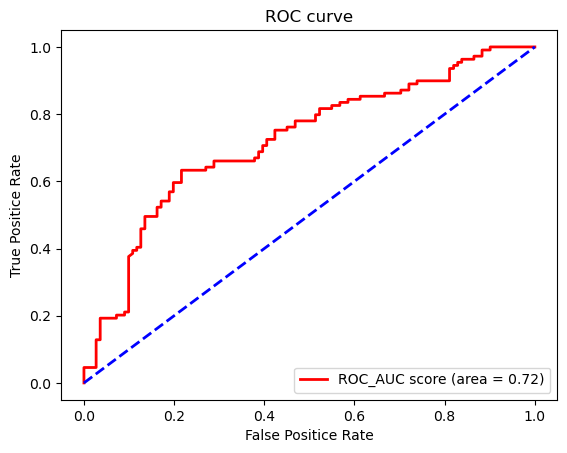

In [55]:
plt.plot(fpr, tpr, color = 'red', lw = 2, label = 'ROC_AUC score (area = %0.2f)'% roc_auc_score(Y_test, y_pred_p))

plt.plot([0, 1], [0, 1], color = 'blue', lw = 2, linestyle = '--')
plt.title('ROC curve')
plt.xlabel('False Positice Rate')
plt.ylabel('True Positice Rate')
plt.legend(loc = 'lower right')
plt.show()

### Regularization (L2 Penalty)

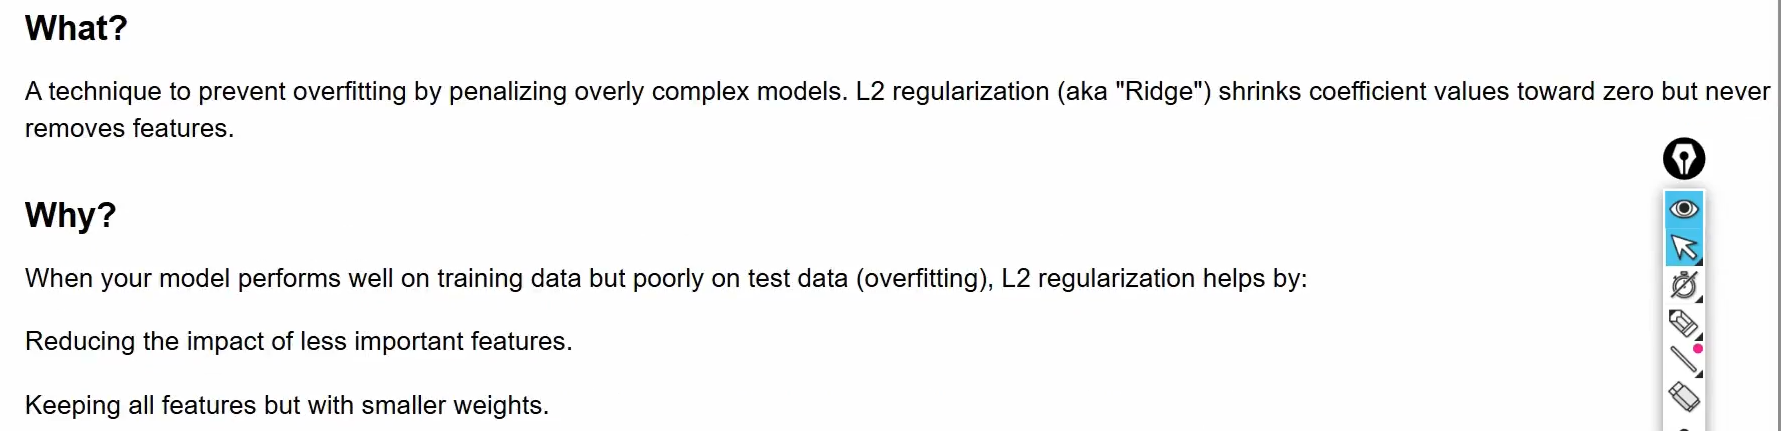

In [59]:
model1 = LogisticRegression(penalty = 'l2', C = 0.2, solver = 'liblinear', random_state = 42)
model1.fit(X_train, Y_train)

# lower c, stronger regularization

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.2
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [61]:
y_pred_t = model1.predict(X_train)

In [62]:
y_pred_test = model1.predict(X_test)

In [66]:
print(accuracy_score(Y_train, y_pred_t))
print(accuracy_score(Y_test, y_pred_test))

0.7157534246575342
0.6727272727272727


### RFE

In [68]:
from sklearn.feature_selection import RFE

In [69]:
feature_select = RFE(model, n_features_to_select = 3)

In [70]:
feature_select.fit(X_train, Y_train)

,estimator,LogisticRegression()
,n_features_to_select,3
,step,1
,verbose,0
,importance_getter,'auto'
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1


In [74]:
X_train.columns[feature_select.support_]

Index(['CLMINSUR', 'SEATBELT', 'LOSS'], dtype='object')

In [75]:
feature_select.ranking_

array([2, 1, 1, 3, 1])

### Cross Validation

Cross-validation is a resampling technique used to evaluate how a machine learning model will perform on new, unseen data. Instead of using the entire dataset just for training, it partitions the data into multiple subsets to ensure every data point is used for both training and testing at different stages.

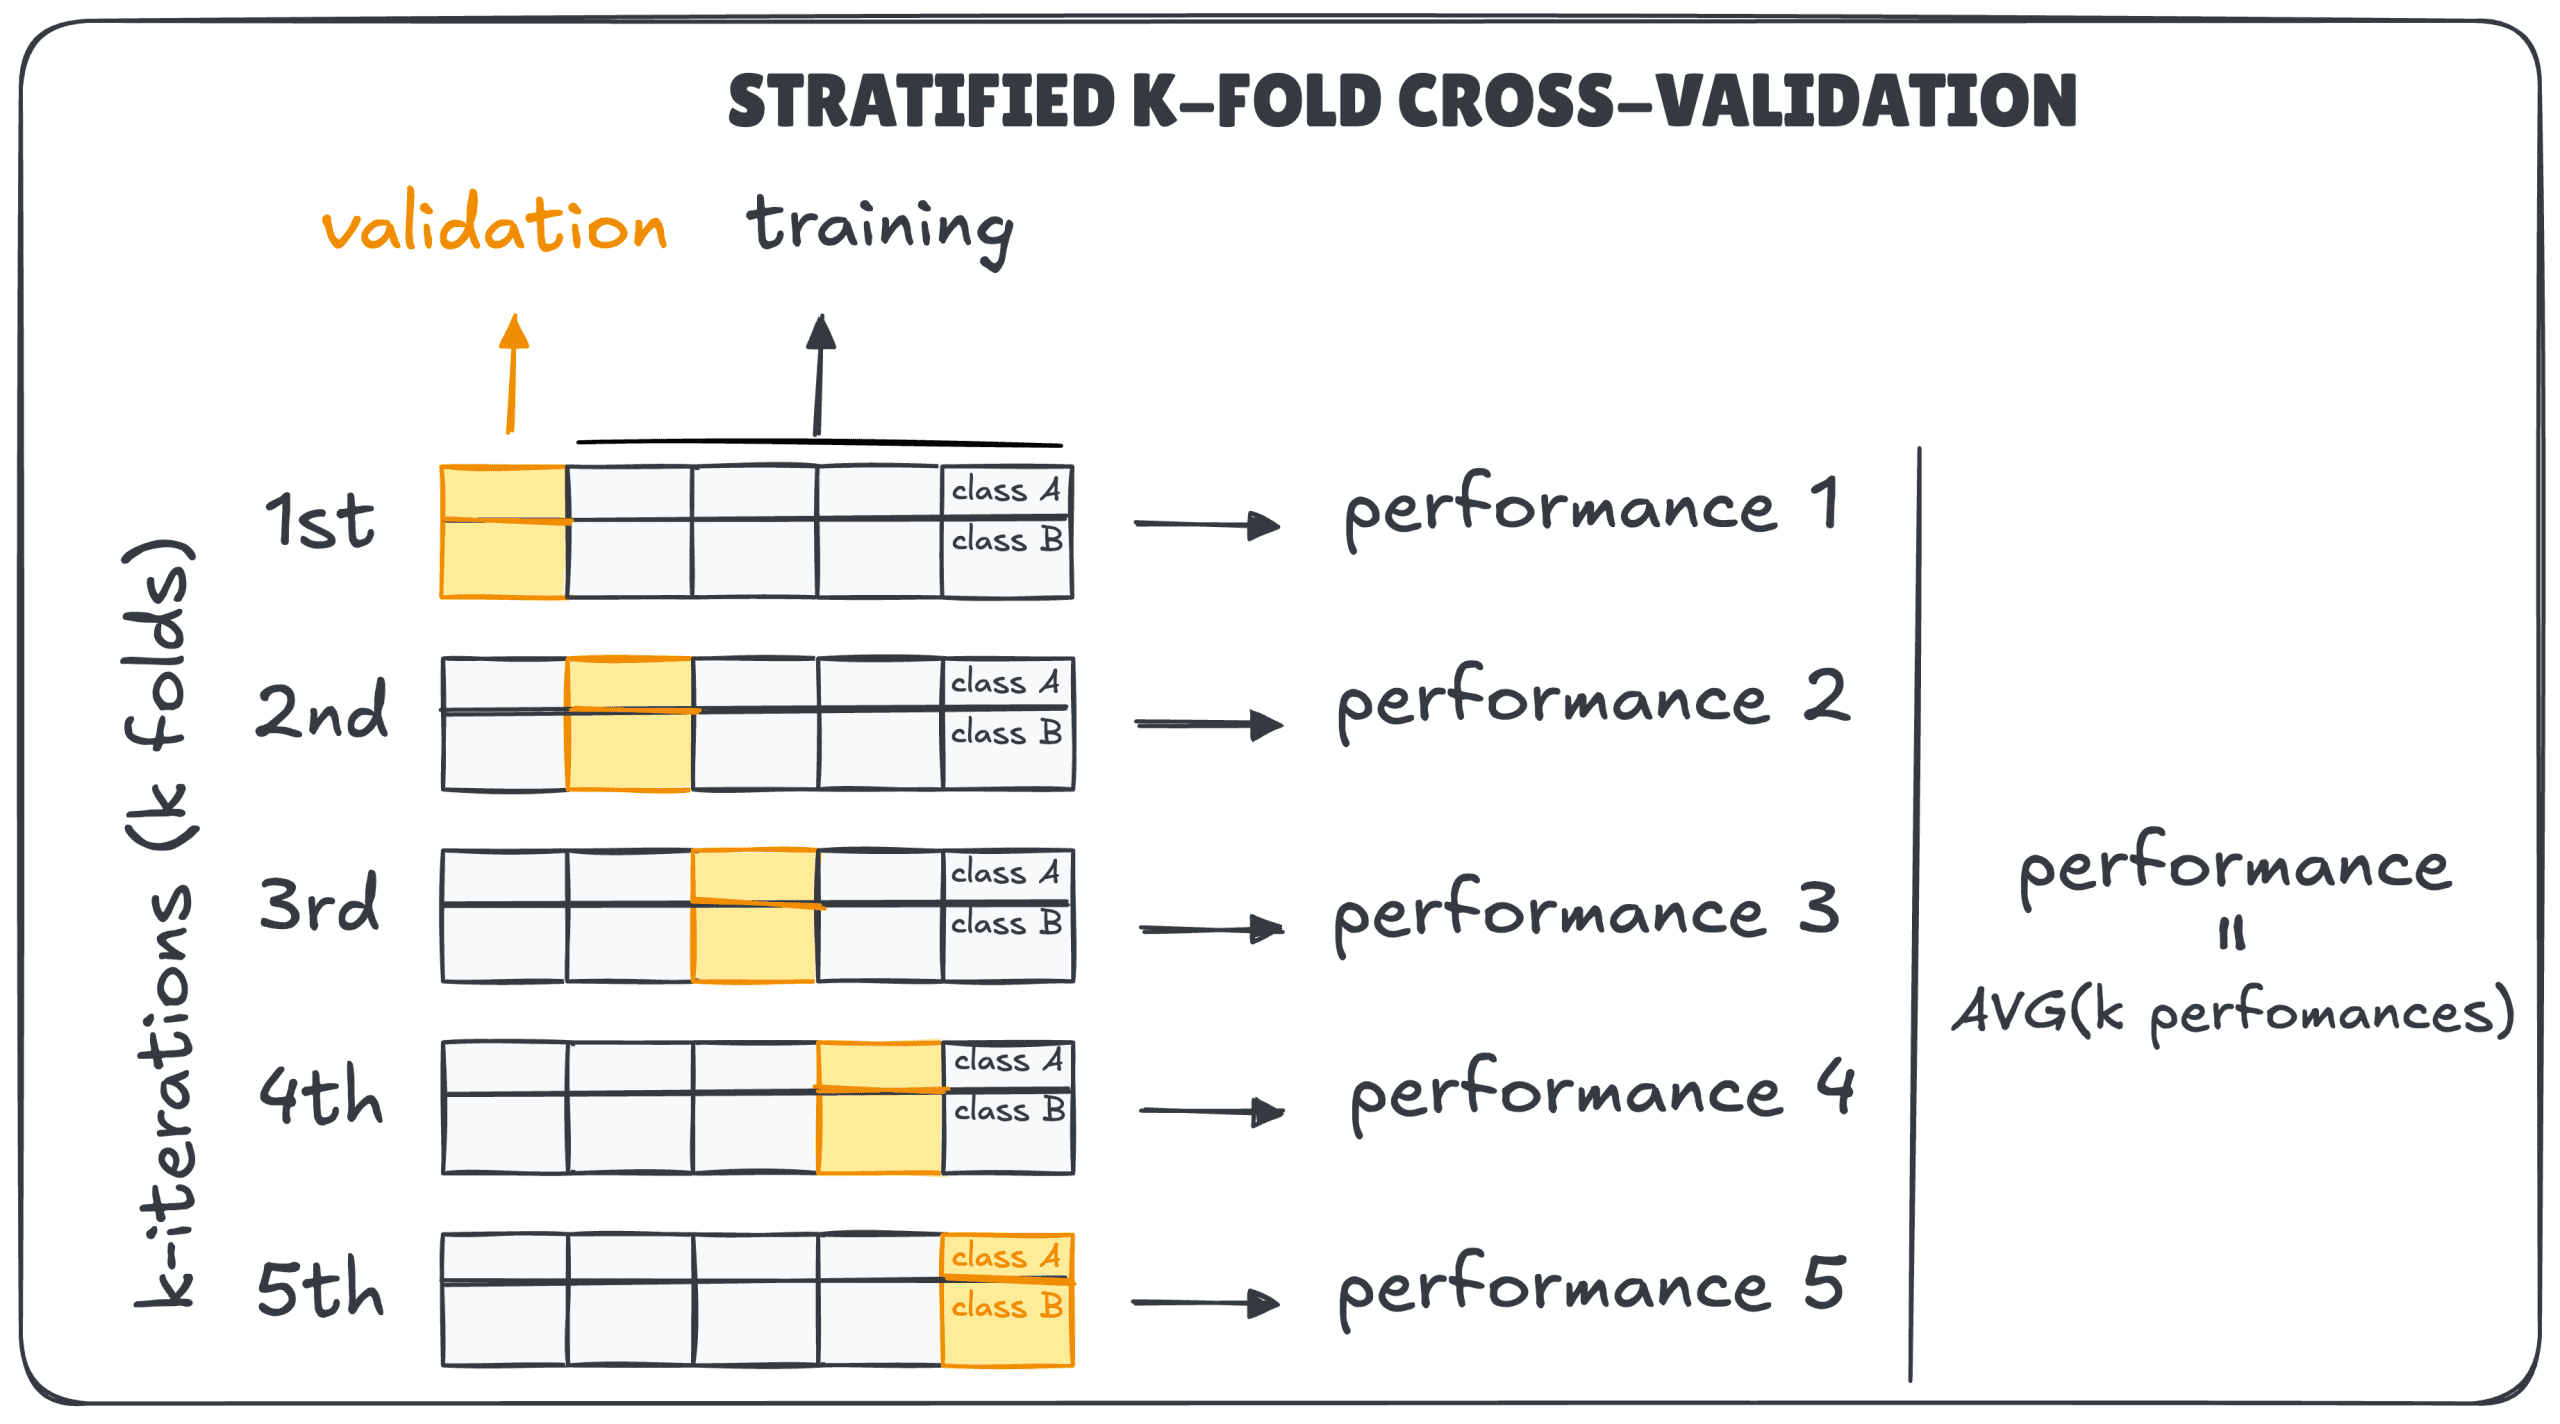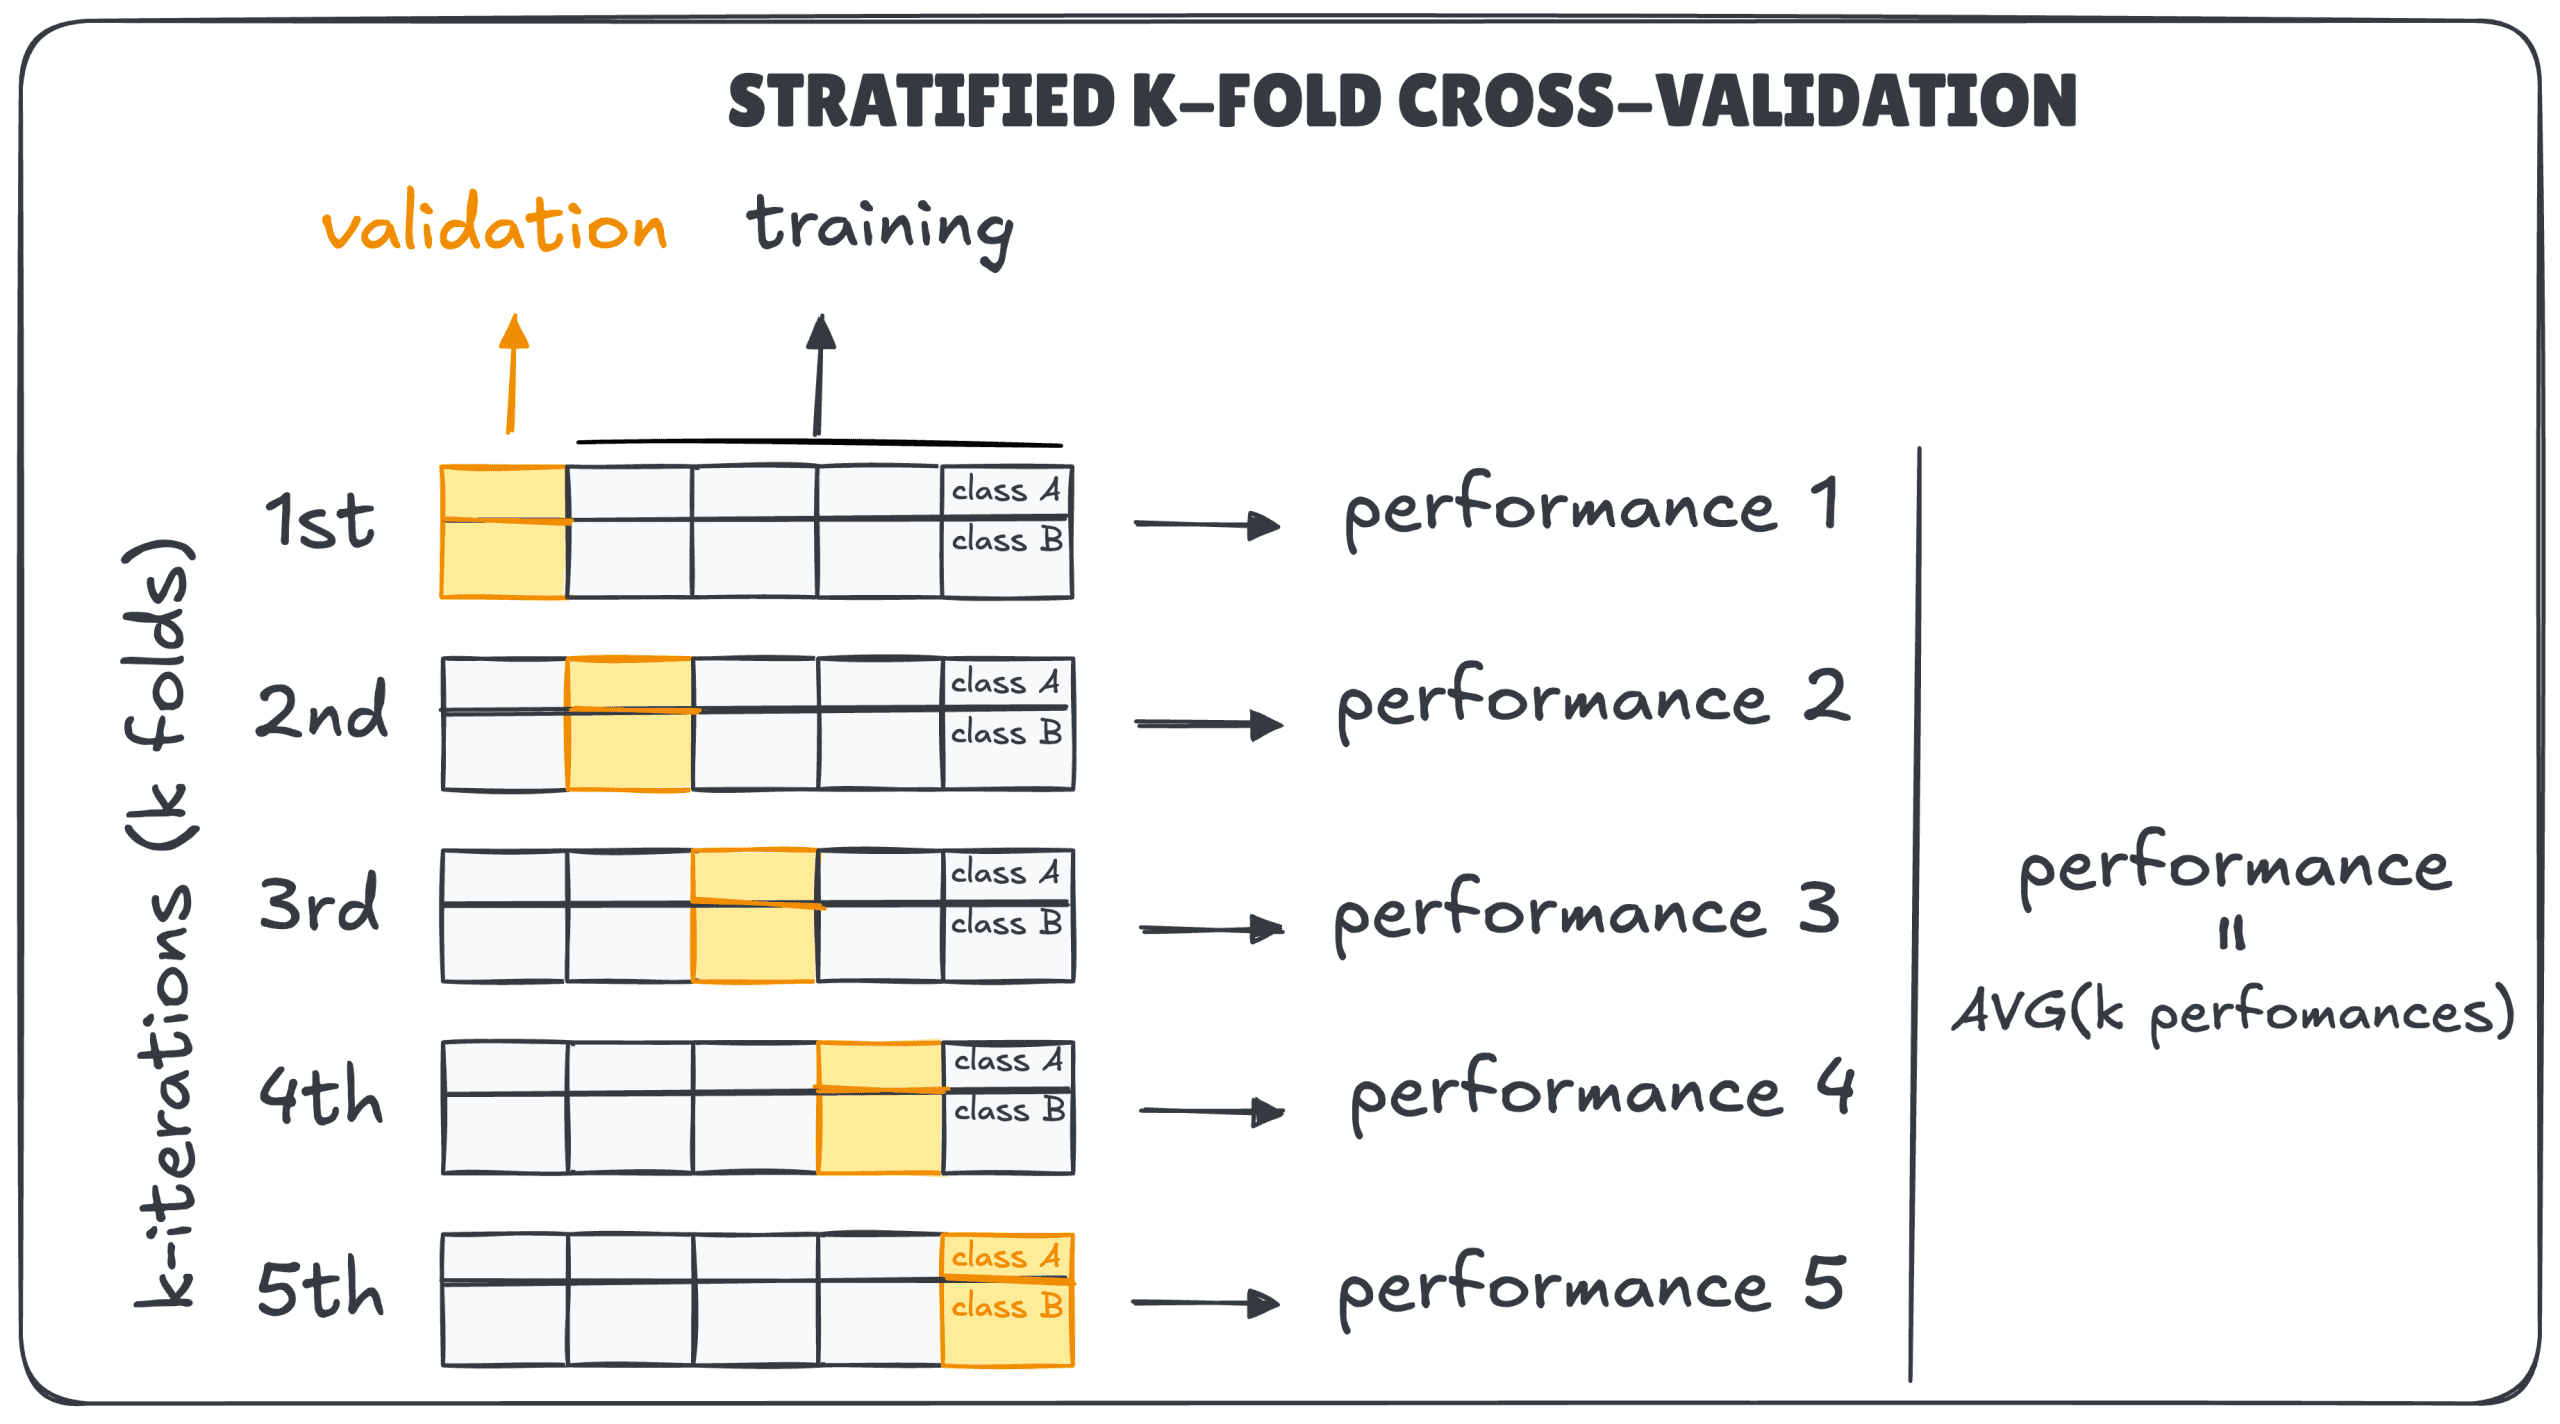

In [80]:
import numpy as np
from sklearn.model_selection import cross_val_score

In [81]:
scores = cross_val_score(model, X_train, Y_train, cv = 5, scoring = 'accuracy')
print(f"Scores per fold: {scores}")
print(f"Average Accuracy: {np.mean(scores):.2f} (+/- {np.std(scores):.2f})")

Scores per fold: [0.71590909 0.73142857 0.69142857 0.68571429 0.74285714]
Average Accuracy: 0.71 (+/- 0.02)
